<a href="https://www.kaggle.com/code/lalit7881/ai-impact-on-jobs-and-layoff-risk-94?scriptVersionId=325301653" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset/ai-impact-jobs-layoff-risk-dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset/ai-impact-jobs-layoff-risk-dataset.csv")

In [3]:
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [4]:
df.tail()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
19995,56,Bachelor's,10,Retail,Sales Associate,Small,Entry,29,62,44,Low,0,4,16,0,Medium
19996,43,Bachelor's,9,Manufacturing,Production Supervisor,Medium,Entry,87,20,20,High,9,23,77,67,High
19997,28,High School,7,Telecom,Support Specialist,Medium,Entry,91,2,49,Medium,2,14,55,10,High
19998,46,Bachelor's,3,Manufacturing,Quality Engineer,Medium,Senior,76,40,89,Medium,3,13,66,5,Medium
19999,36,Bachelor's,5,Retail,Store Manager,Medium,Mid,45,65,75,Low,1,0,30,8,Medium


In [5]:
df.describe()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [7]:
df.isnull()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Age                            int64
Education_Level               object
Years_of_Experience            int64
Industry                      object
Job_Role                      object
Company_Size                  object
Job_Level                     object
Routine_Task_Percentage        int64
Creativity_Requirement         int64
Human_Interaction_Level        int64
AI_Adoption_Level             object
Number_of_AI_Tools_Used        int64
AI_Usage_Hours_Per_Week        int64
Tasks_Automated_Percentage     int64
AI_Training_Hours              int64
Layoff_Risk                   object
dtype: object

In [11]:
df.shape

(20000, 16)

In [12]:
df.nunique()

Age                            40
Education_Level                 4
Years_of_Experience            27
Industry                        8
Job_Role                       24
Company_Size                    3
Job_Level                       3
Routine_Task_Percentage        85
Creativity_Requirement        101
Human_Interaction_Level        80
AI_Adoption_Level               3
Number_of_AI_Tools_Used        11
AI_Usage_Hours_Per_Week        31
Tasks_Automated_Percentage     90
AI_Training_Hours              80
Layoff_Risk                     3
dtype: int64

In [13]:
df.columns

Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='object')

## EDA

DATASET SHAPE
(20000, 16)

FIRST 5 ROWS
   Age Education_Level  Years_of_Experience       Industry  \
0   59        Master's                    6        Finance   
1   44        Master's                   14  Manufacturing   
2   36      Bachelor's                    7         Retail   
3   27      Bachelor's                    6        Finance   
4   49     High School                   12        Finance   

                Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
0             Accountant       Medium     Entry                       84   
1  Production Supervisor        Small     Entry                       30   
2          Store Manager       Medium    Senior                       12   
3                Auditor        Large     Entry                       90   
4                Auditor        Small     Entry                       49   

   Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
0                      21                       94        

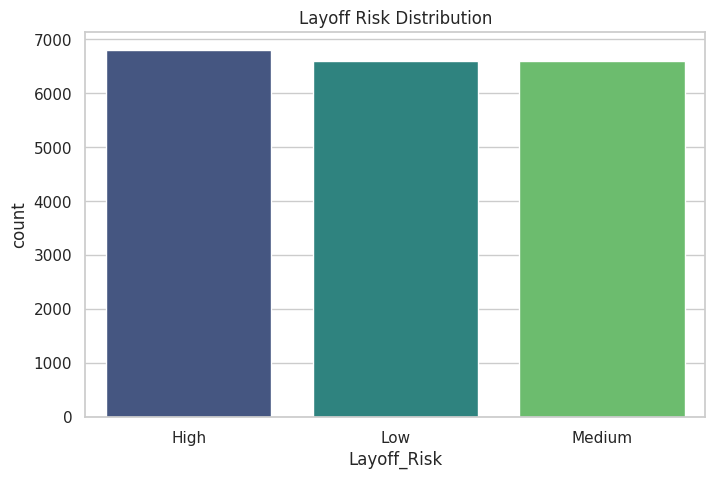

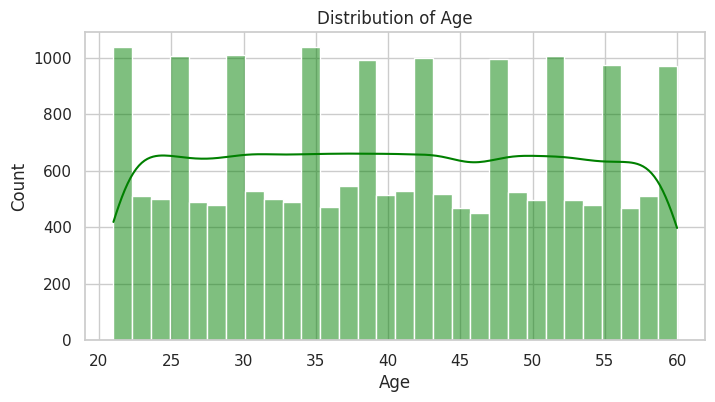

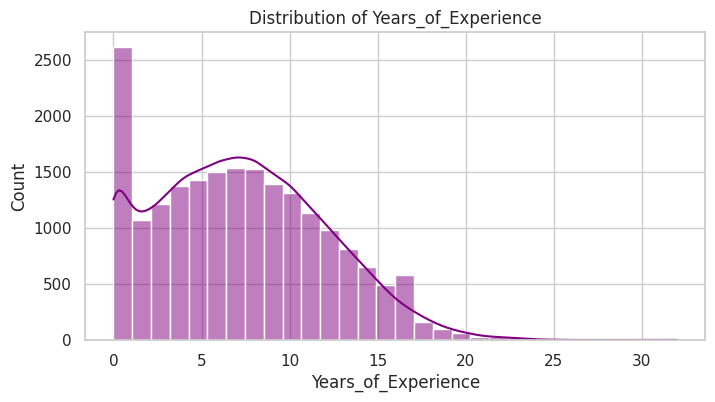

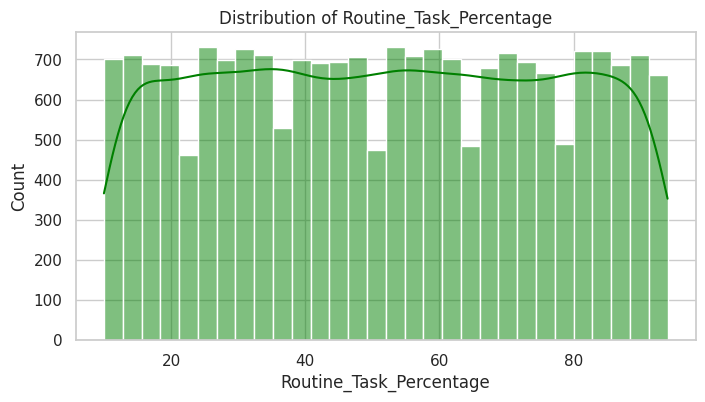

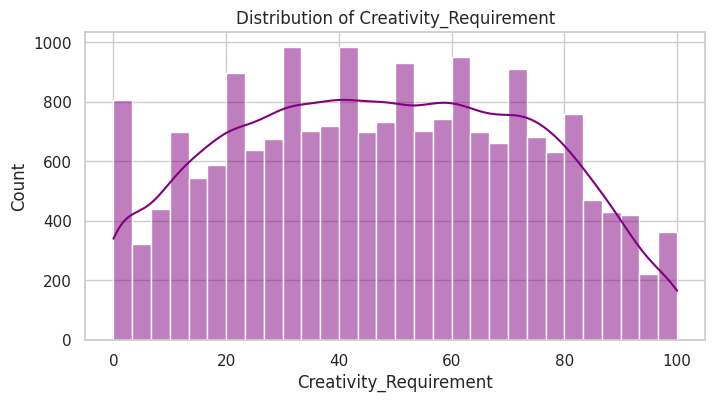

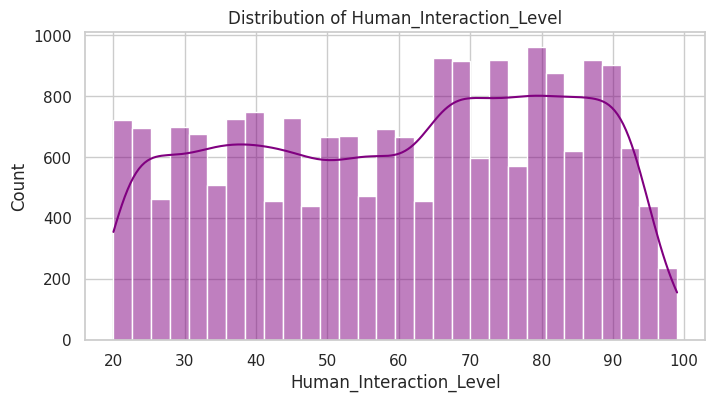

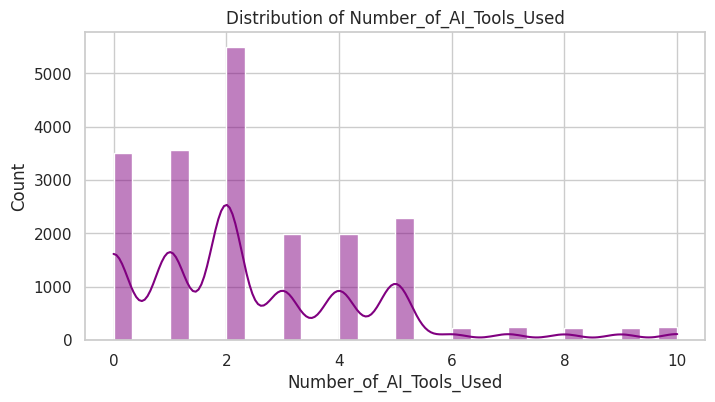

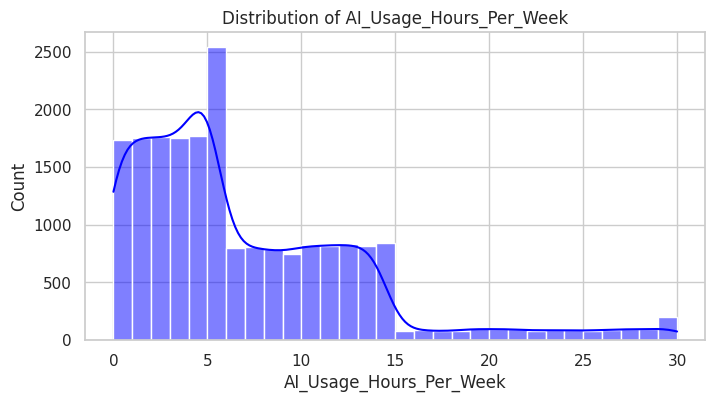

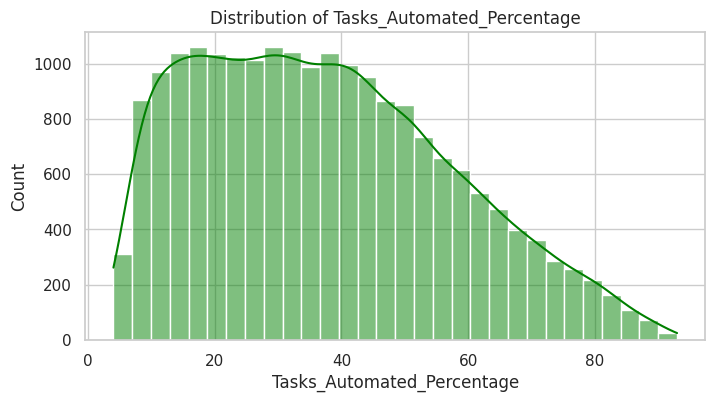

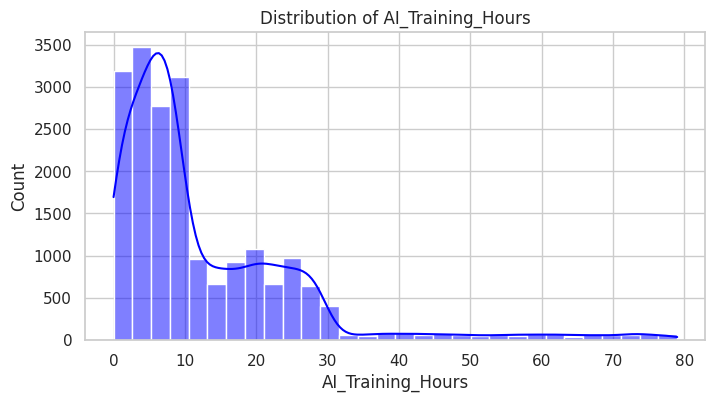

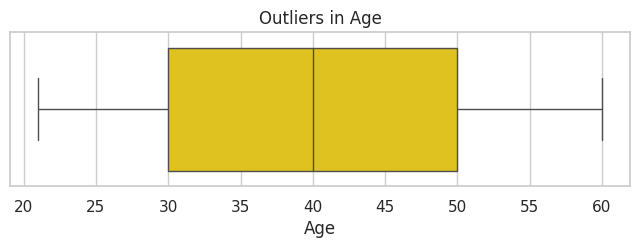

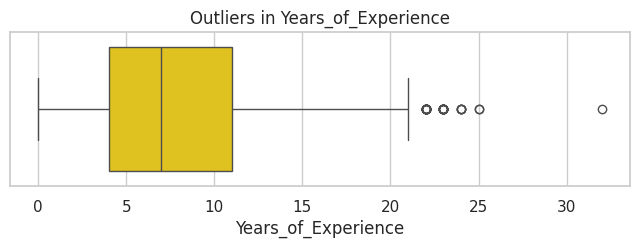

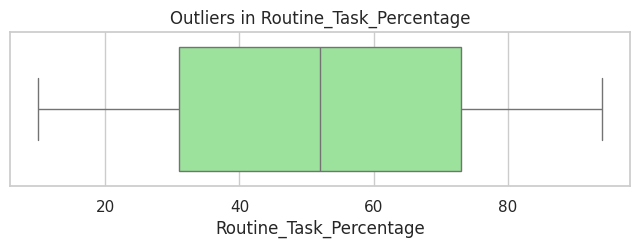

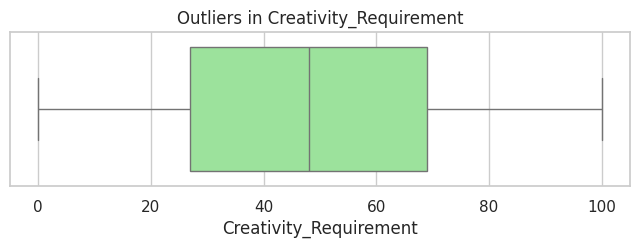

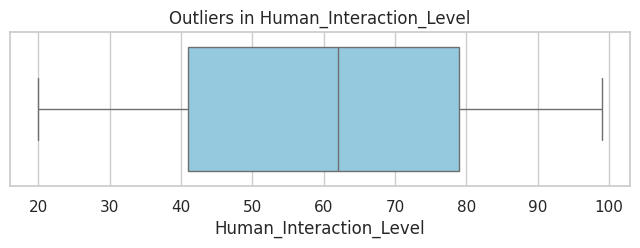

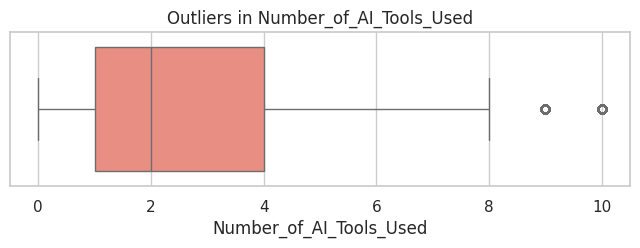

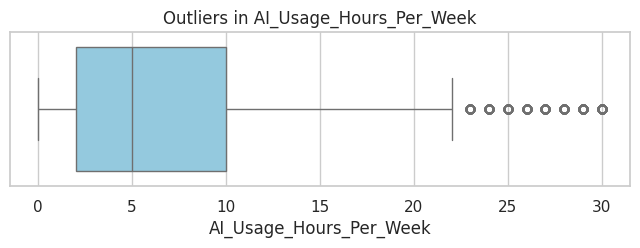

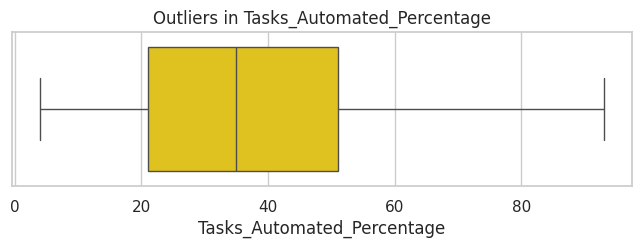

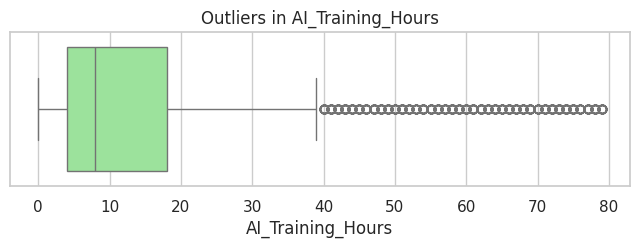

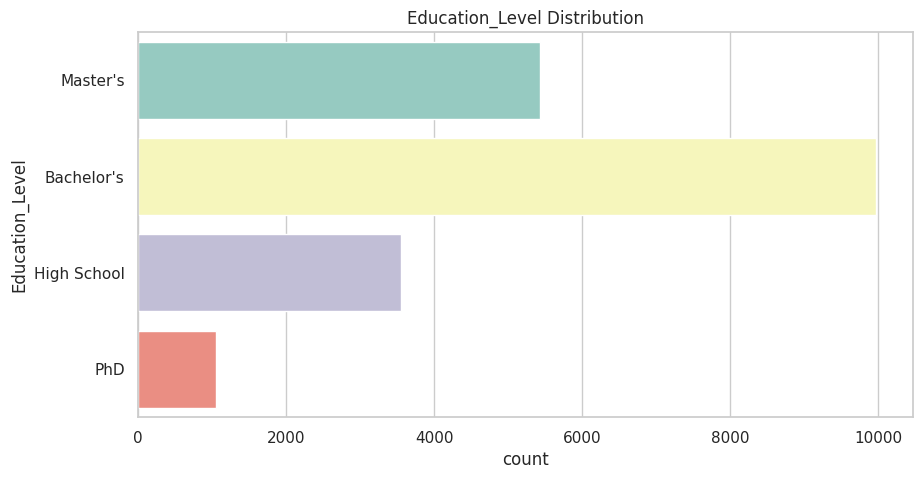

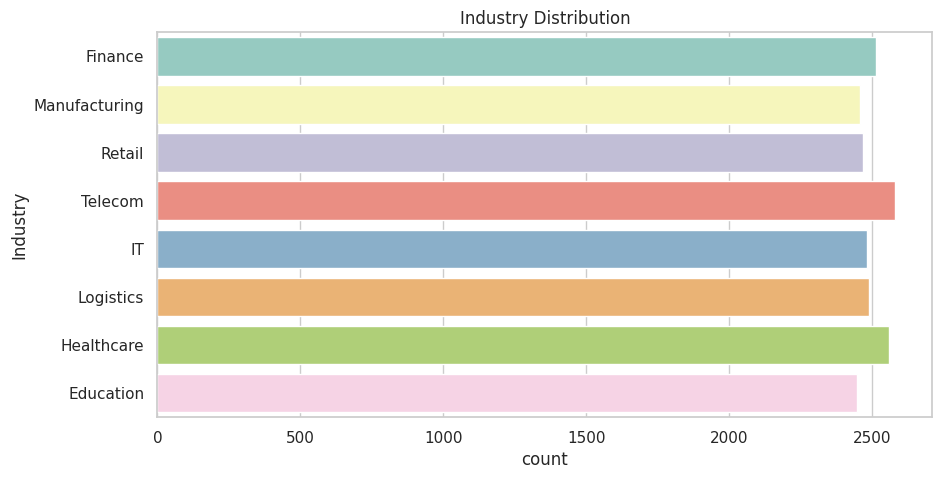

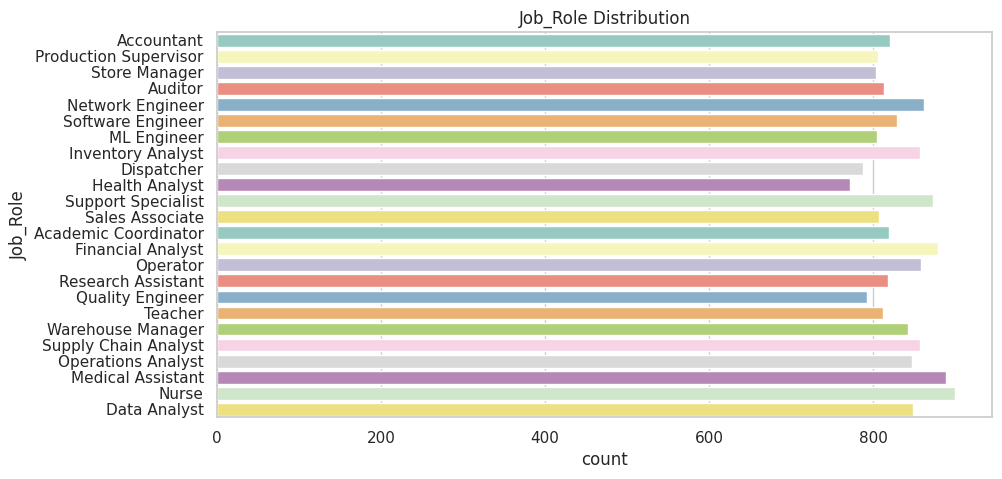

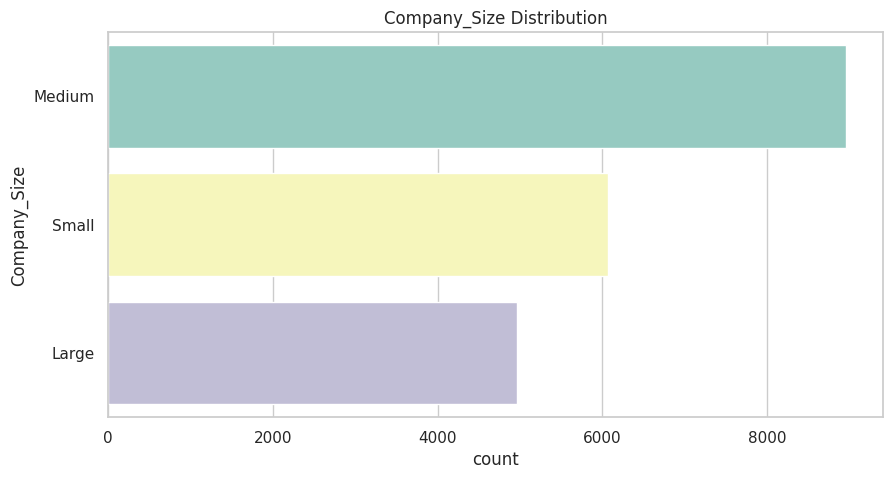

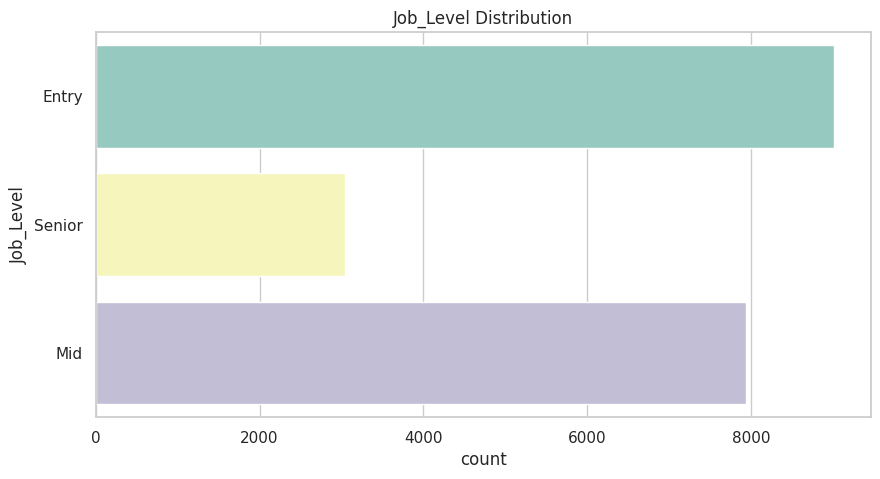

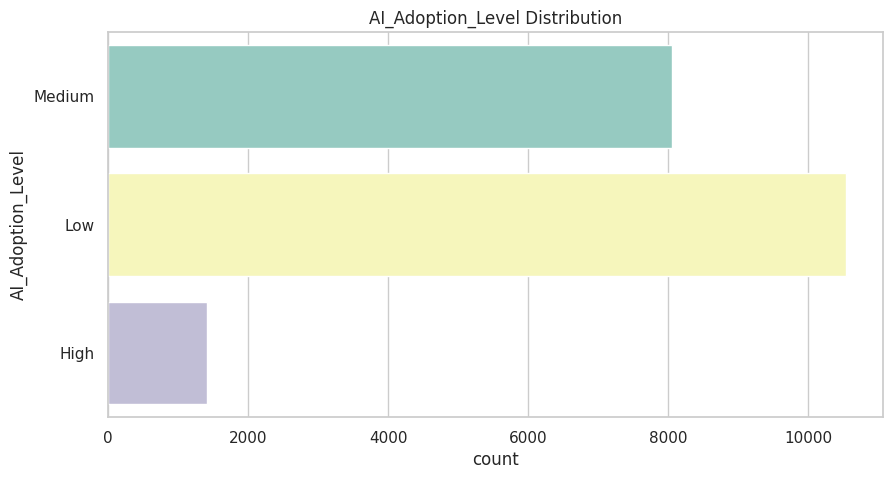

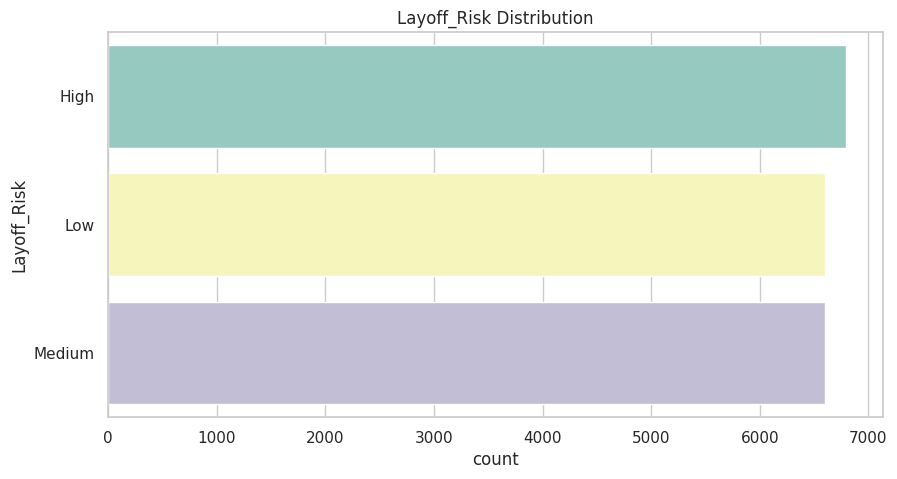

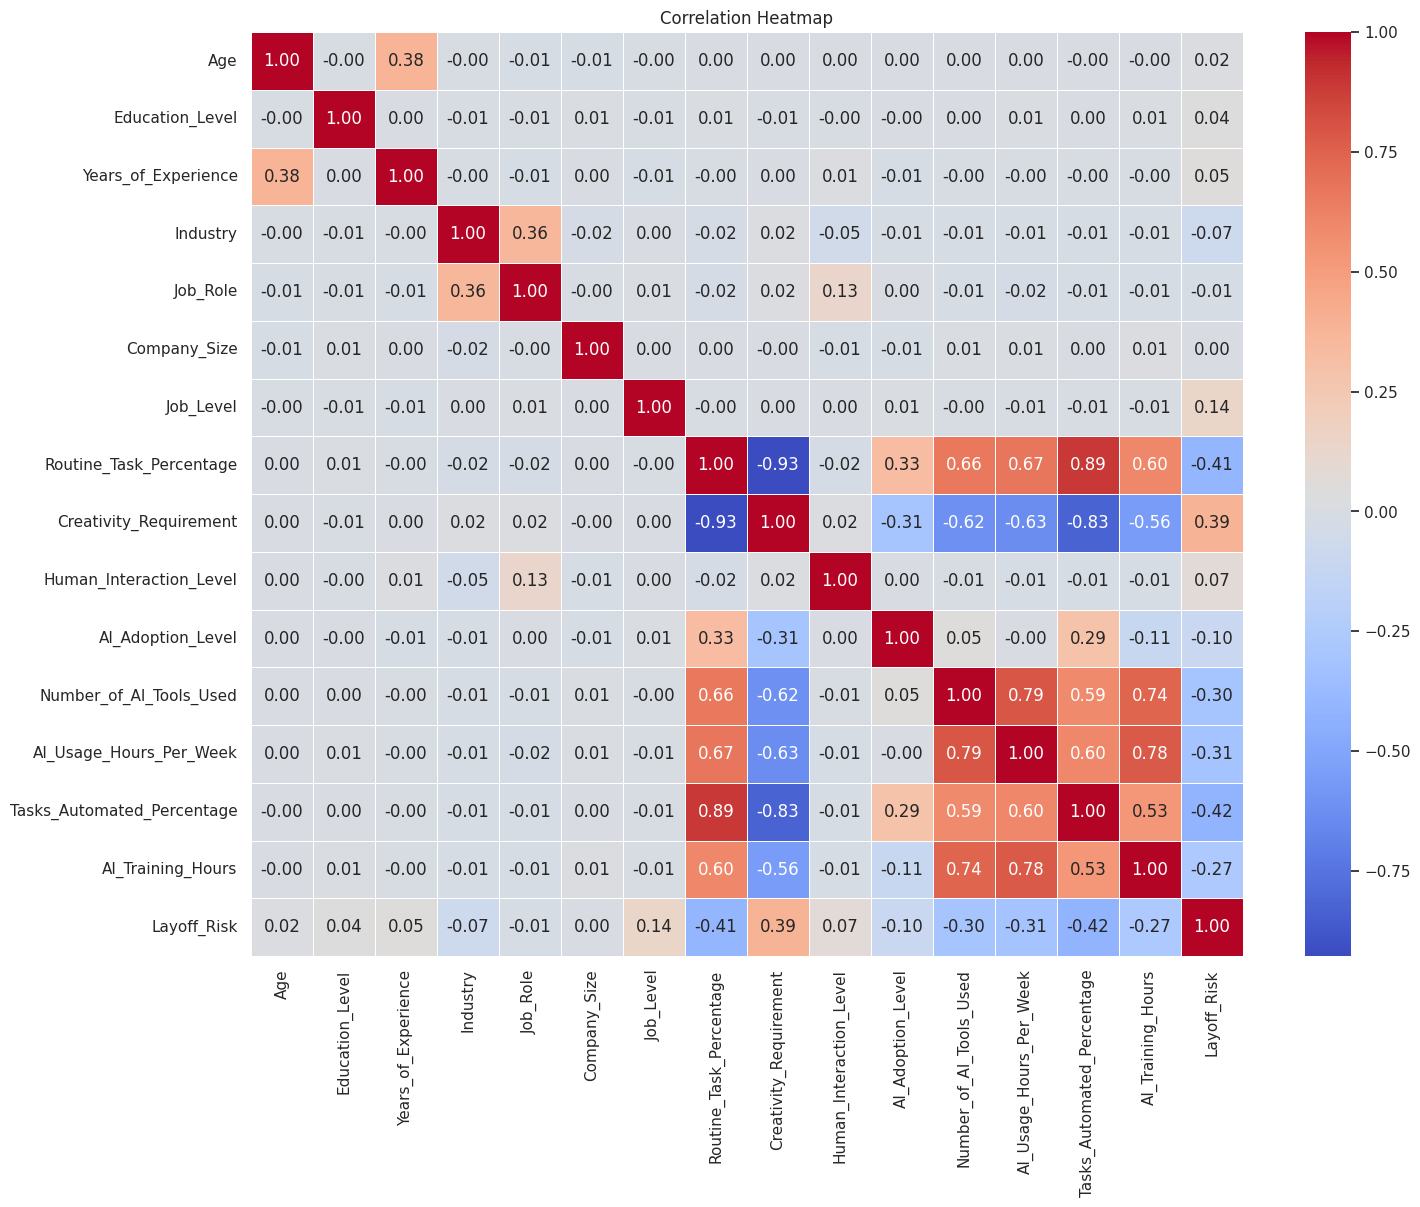

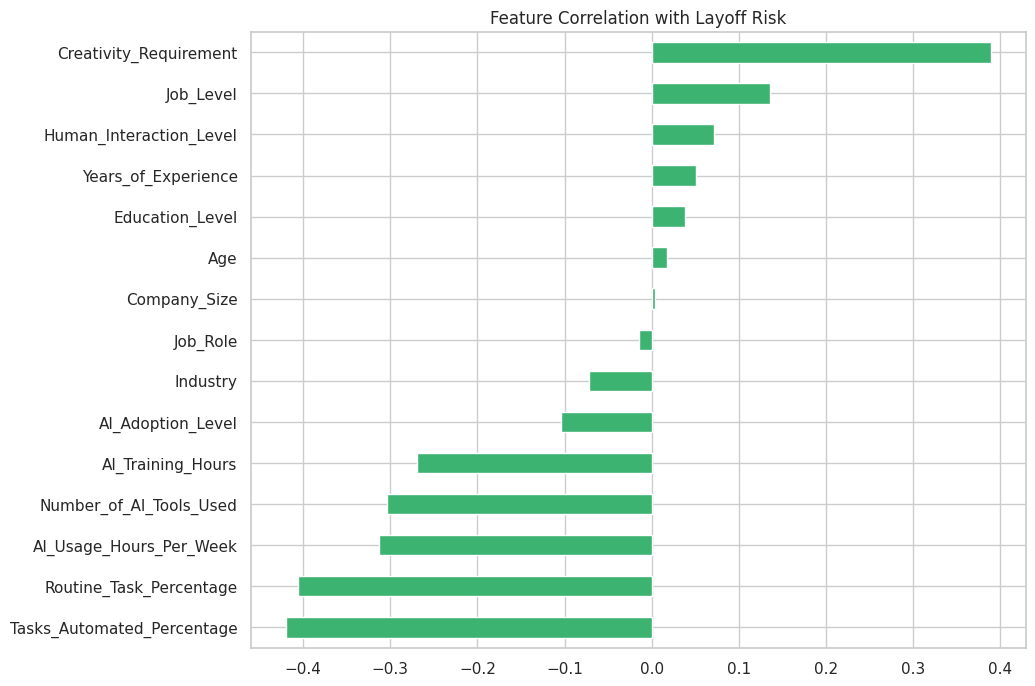

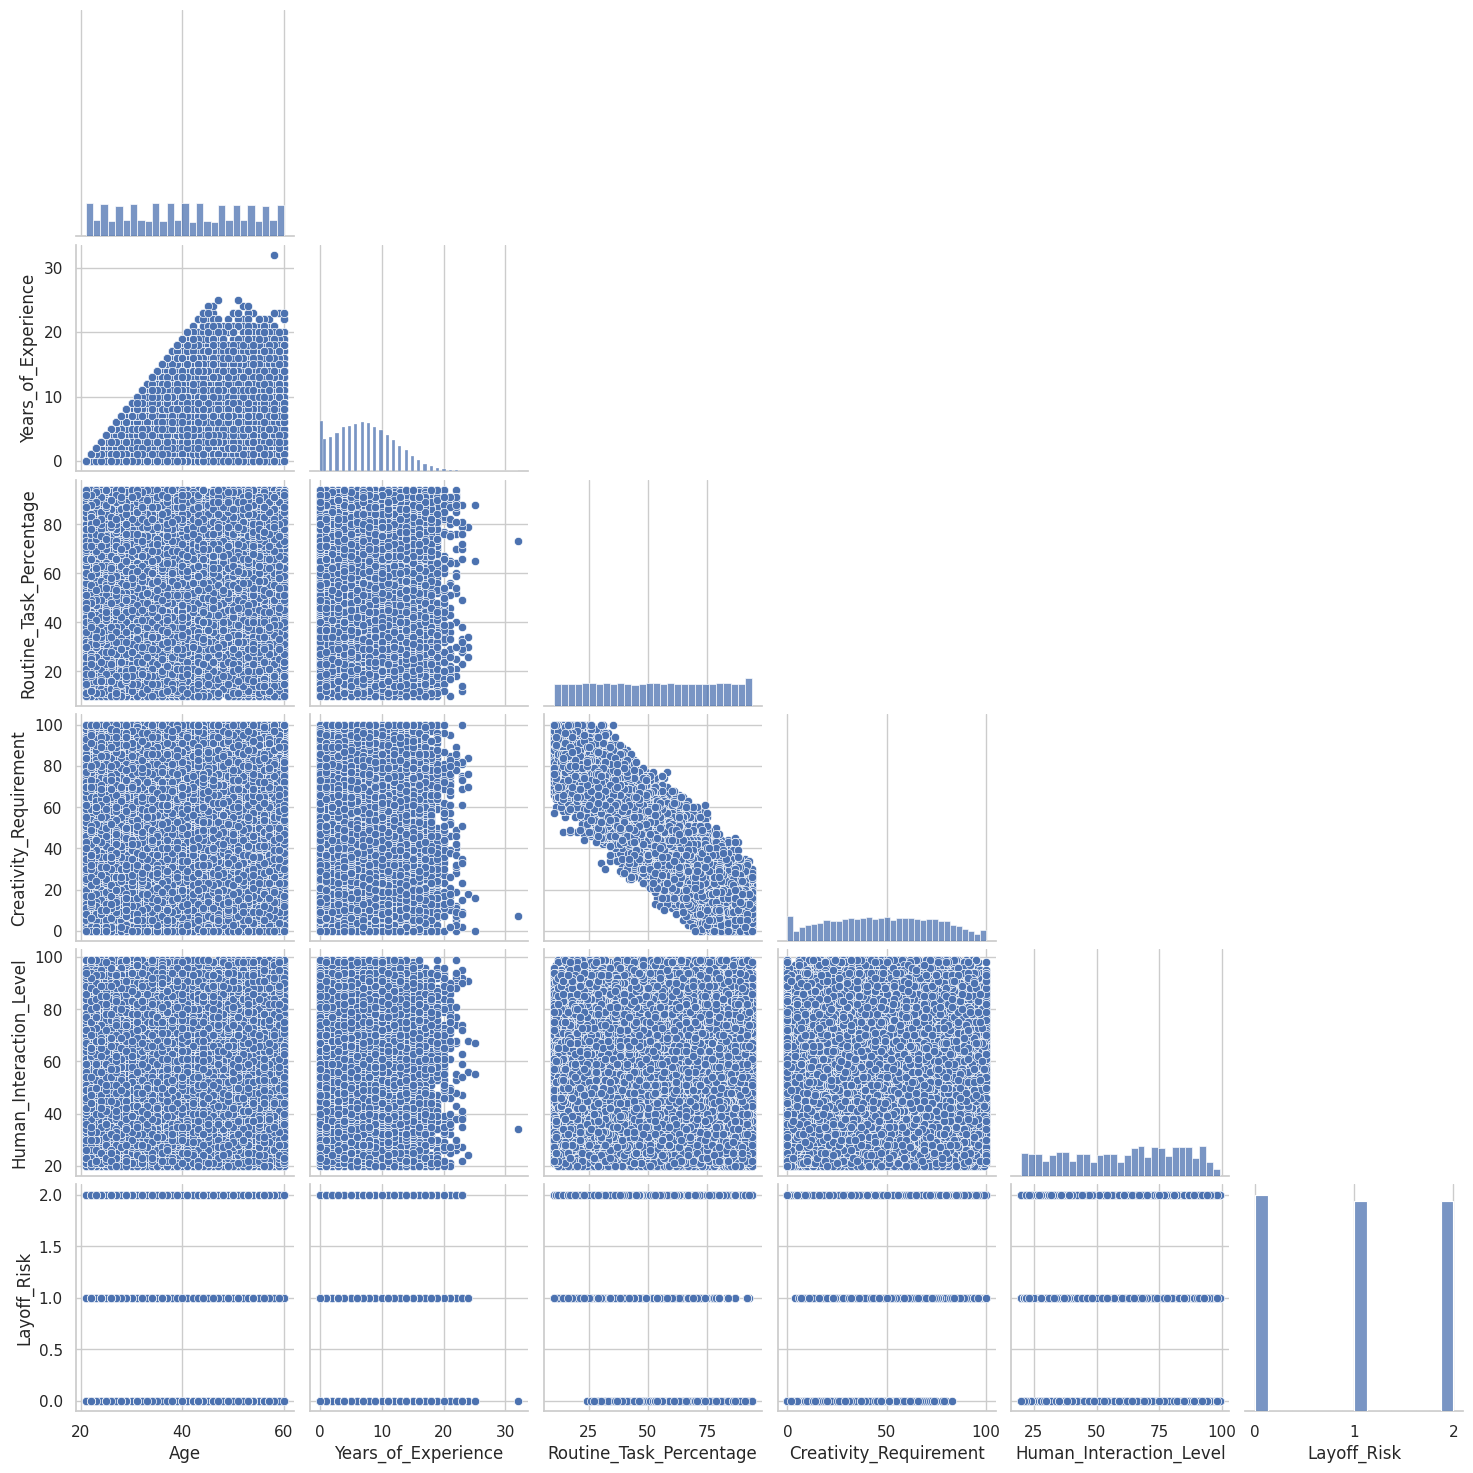

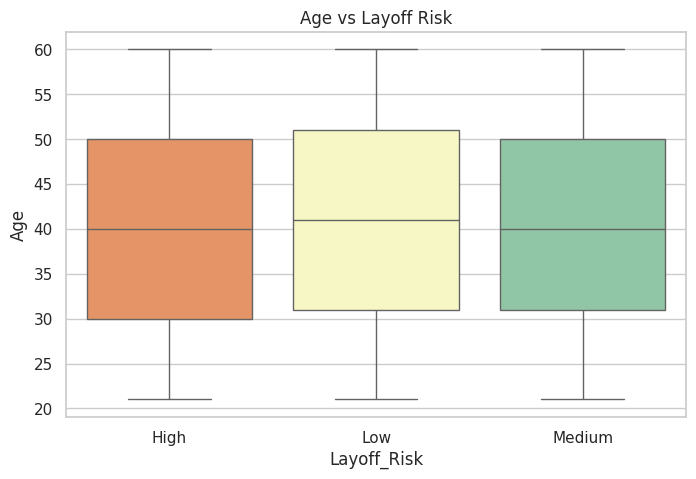

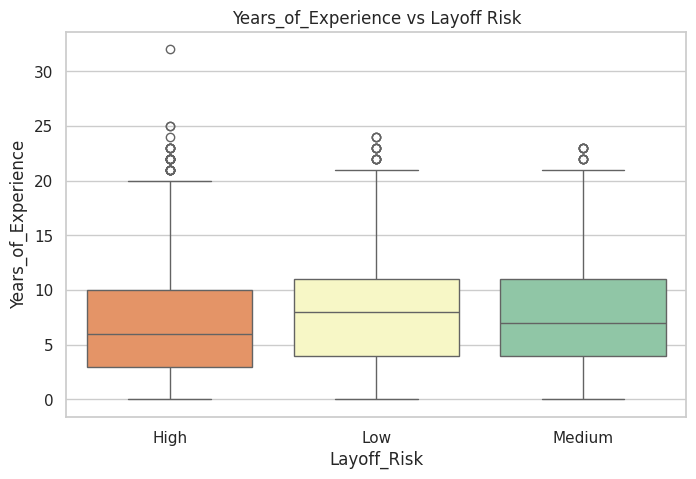

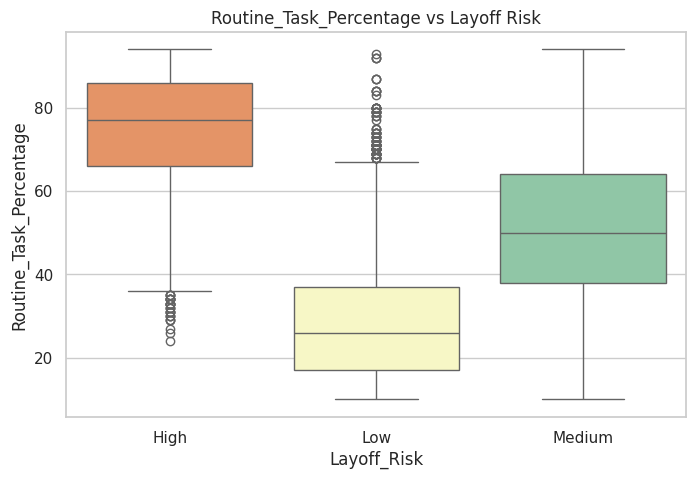

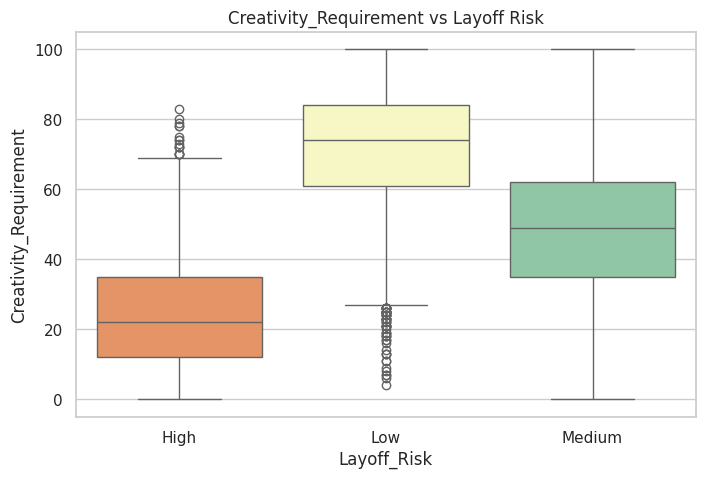

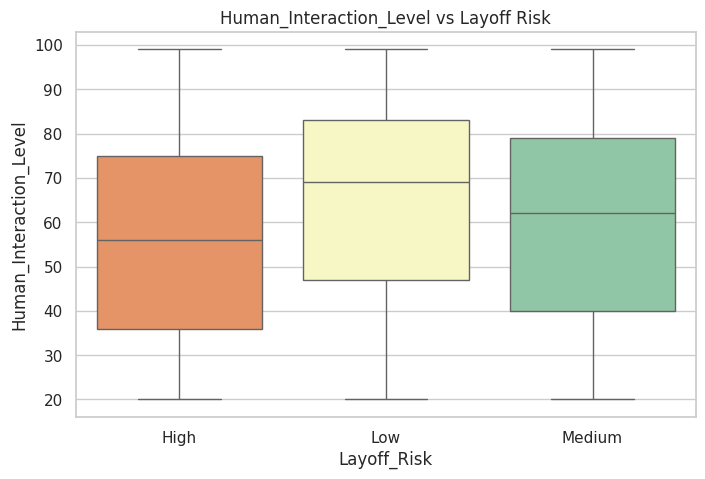

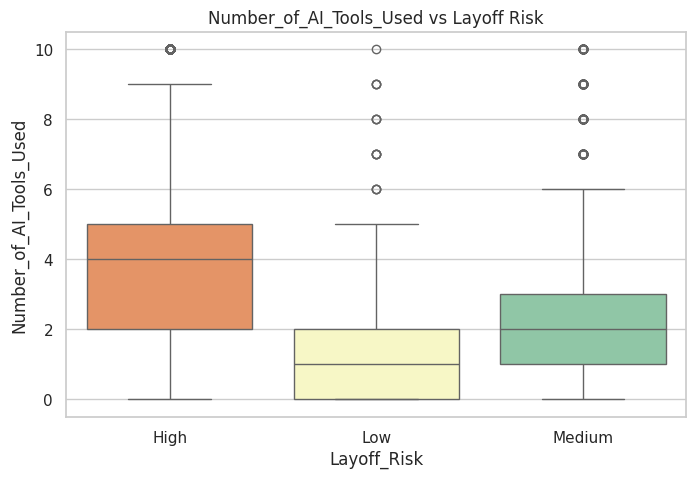

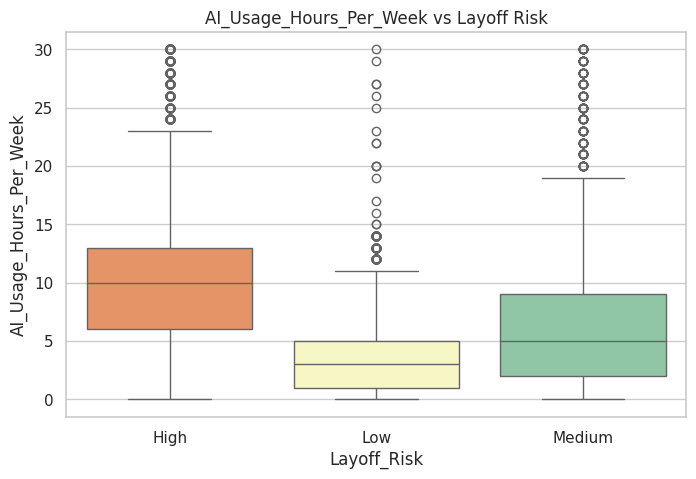

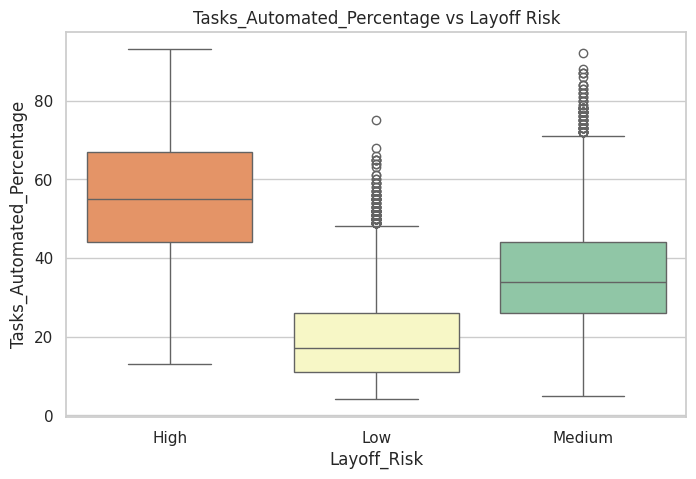

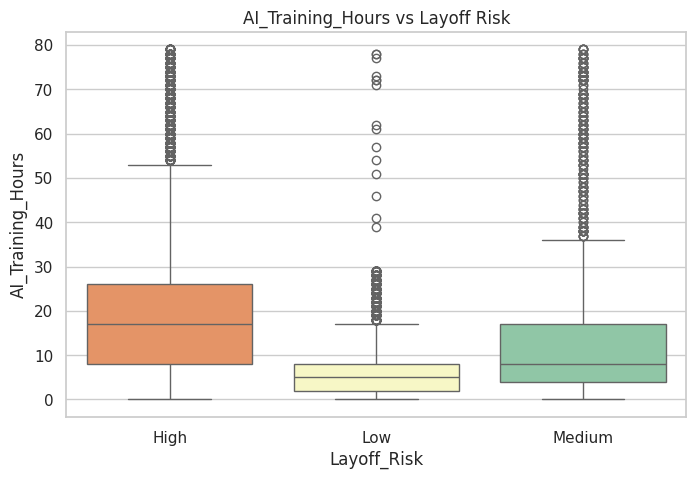

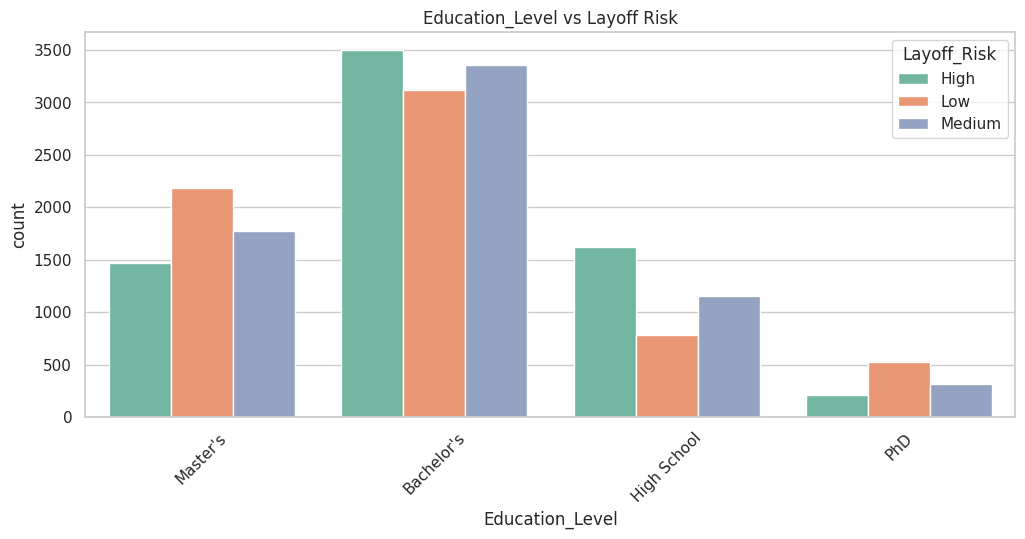

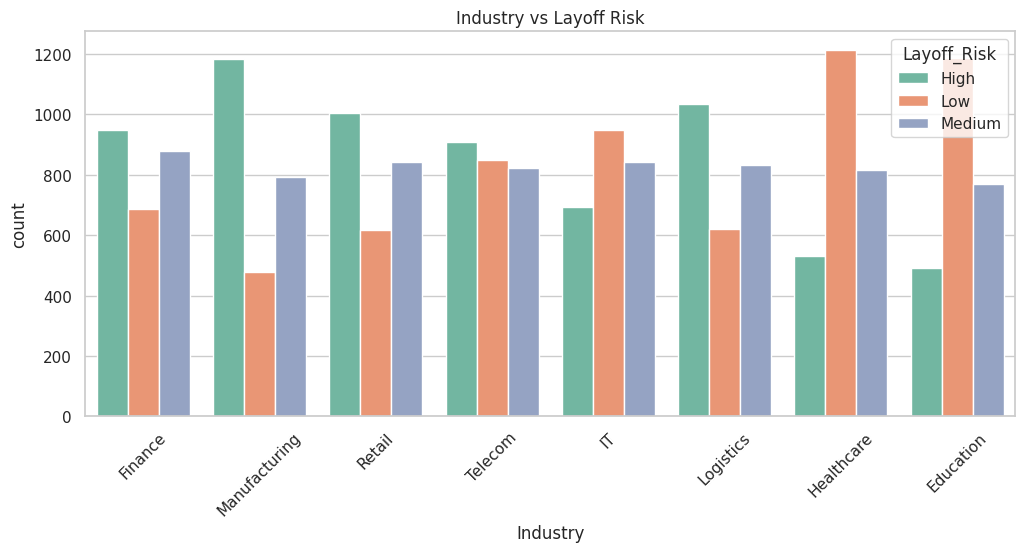

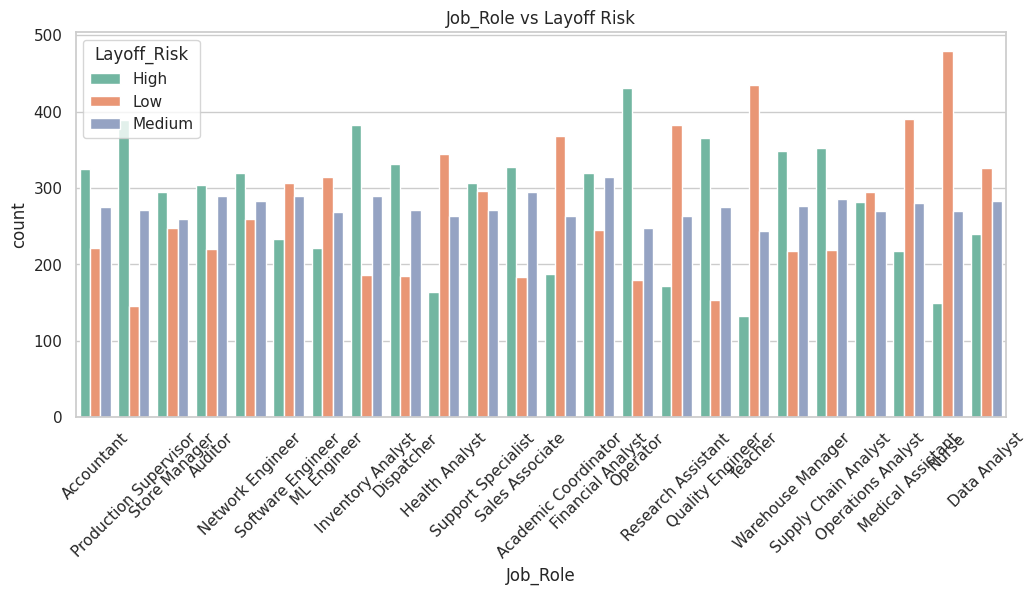

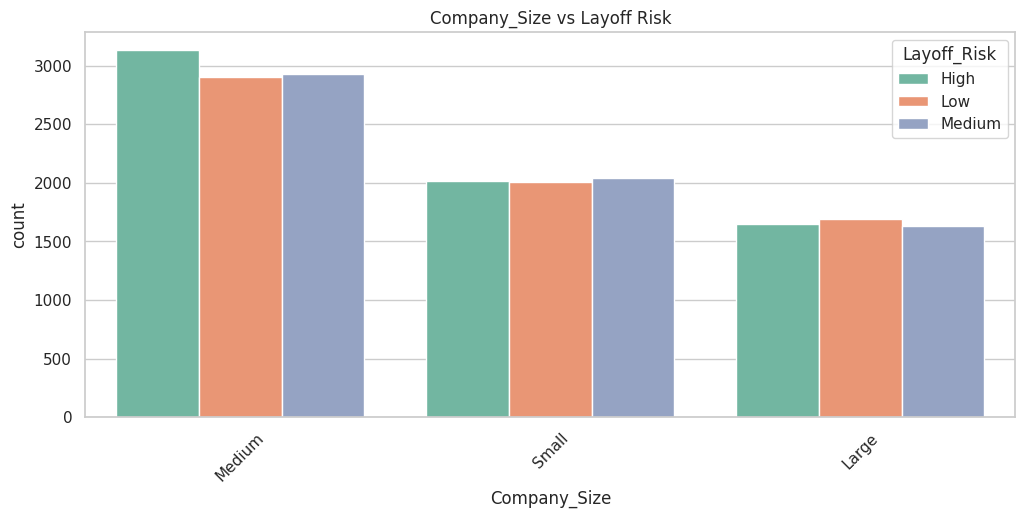

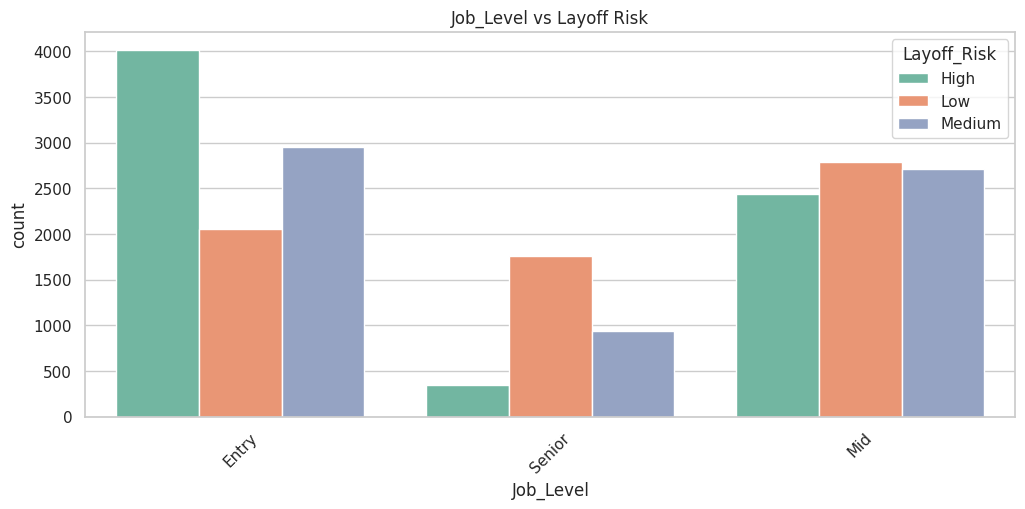

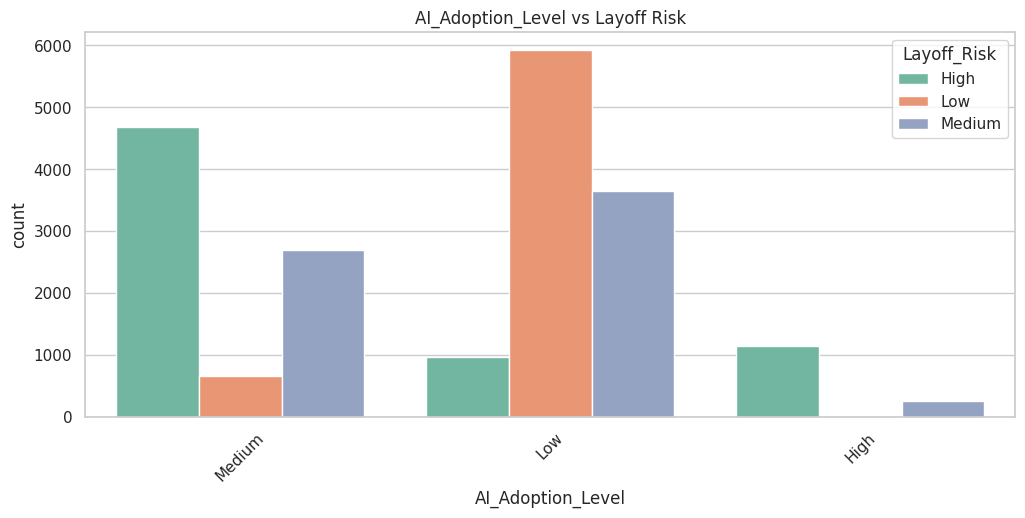

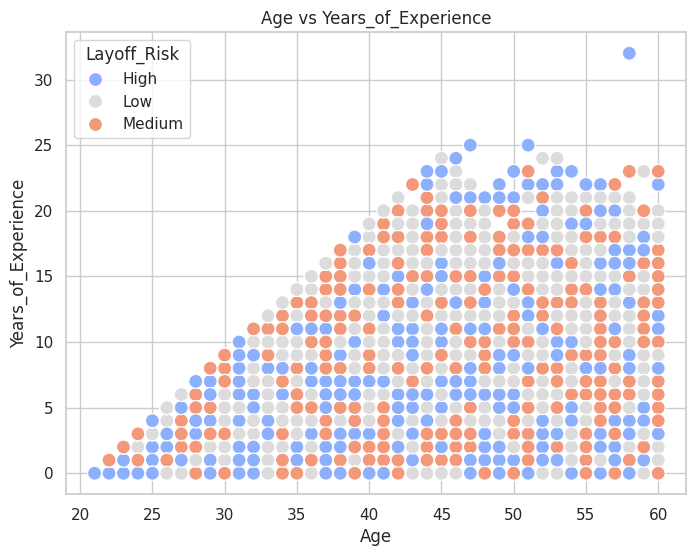

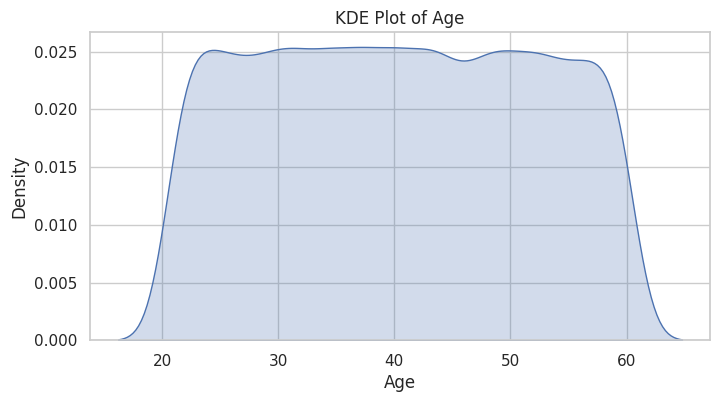

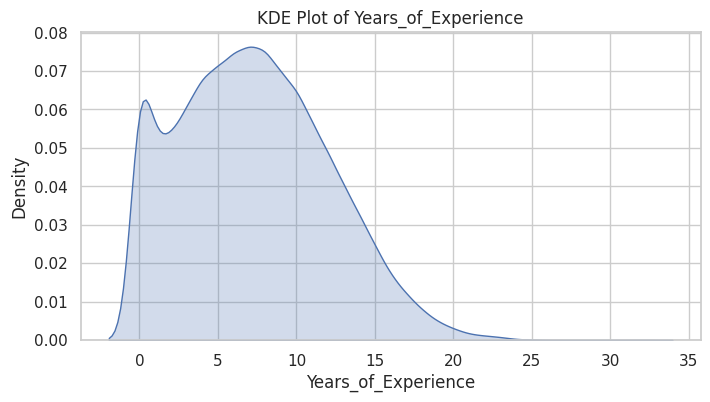

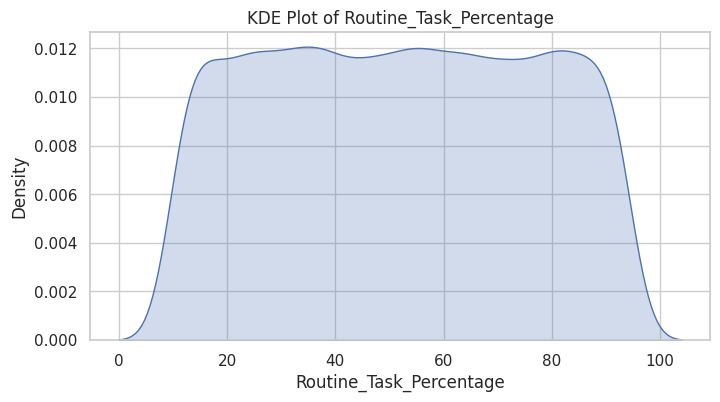

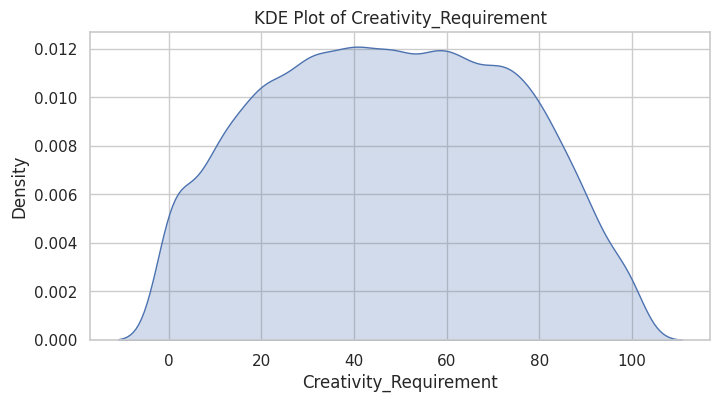

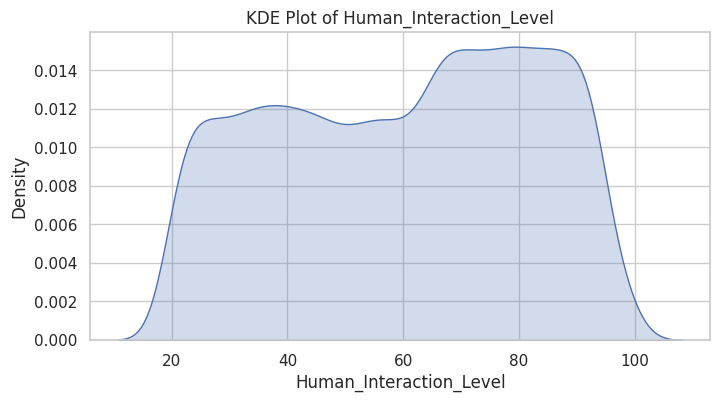

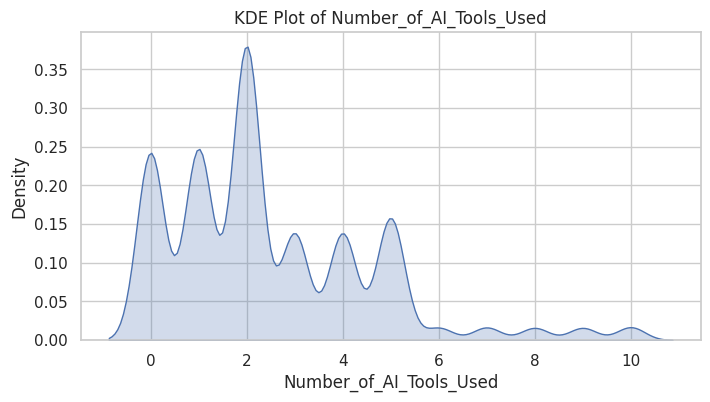

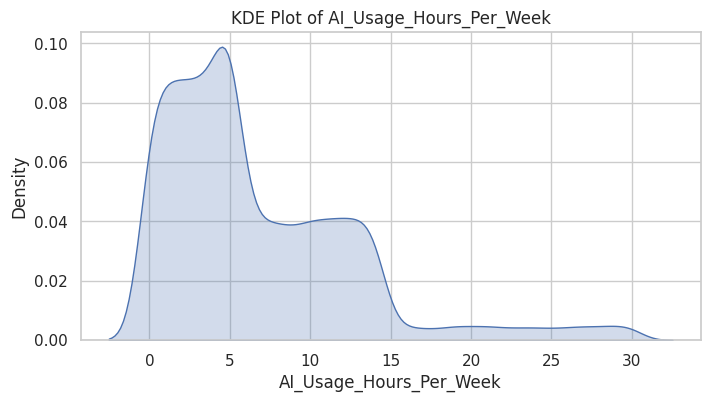

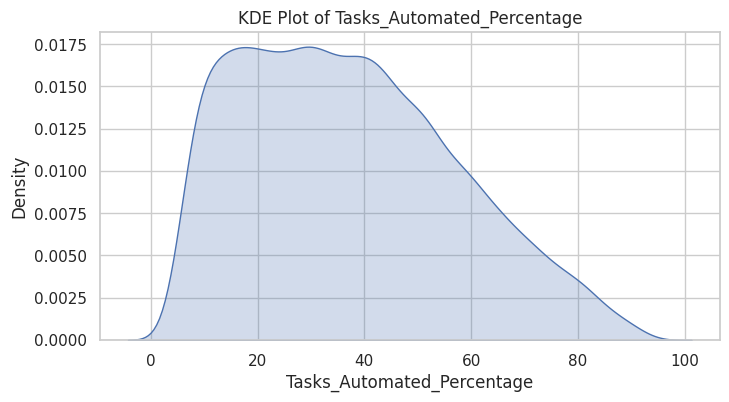

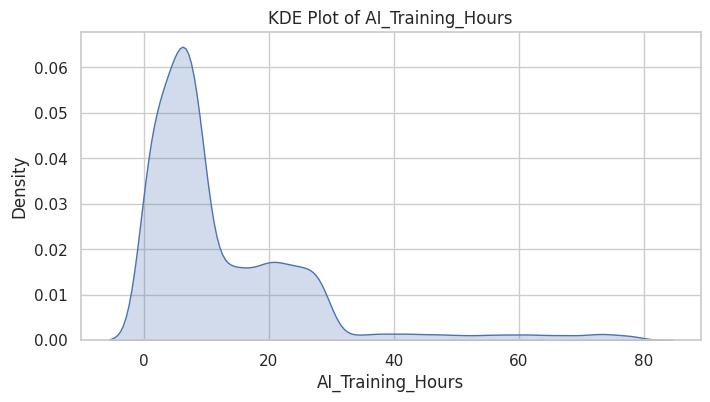

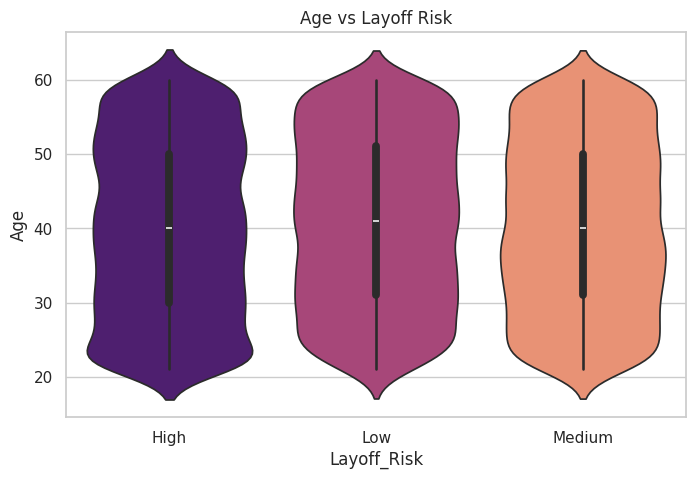

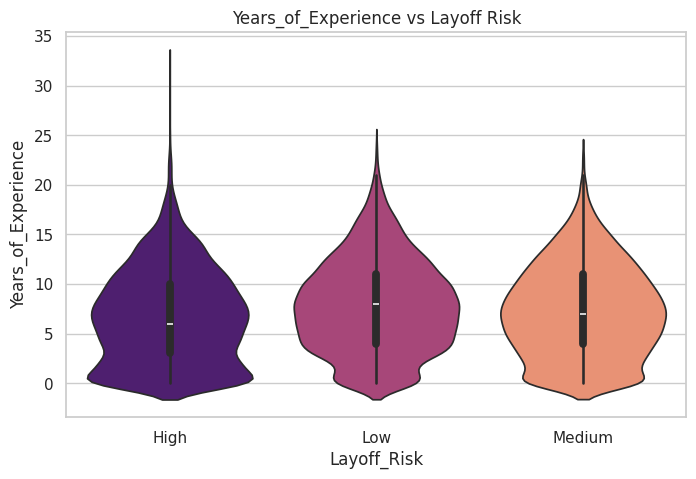

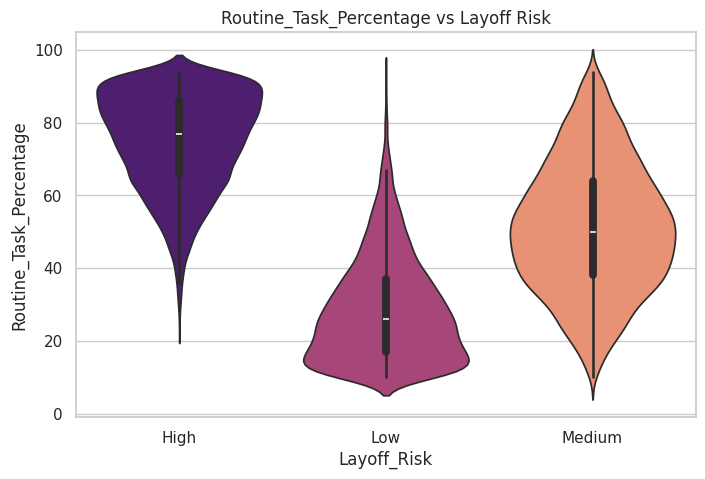

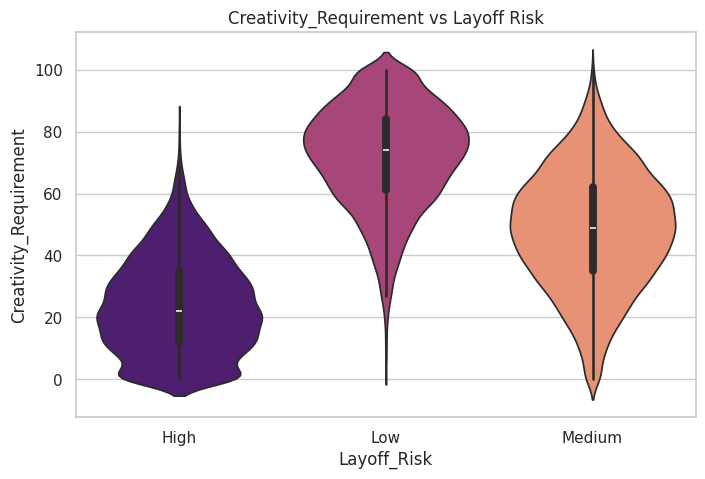

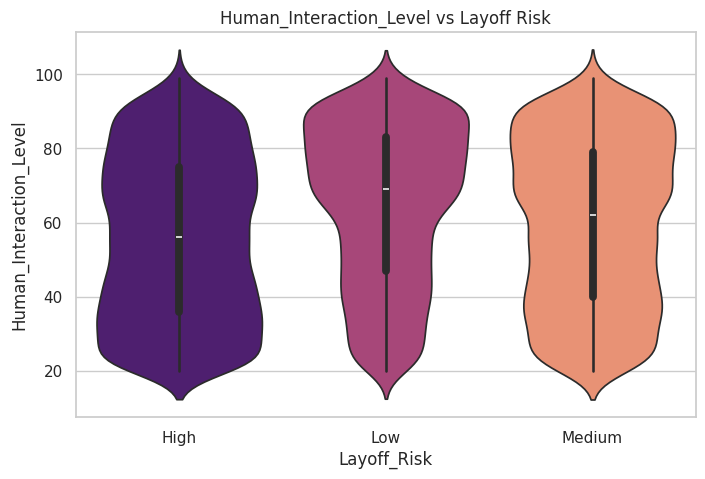


SUMMARY STATISTICS
                 Age Education_Level  Years_of_Experience Industry Job_Role  \
count   20000.000000           20000         20000.000000    20000    20000   
unique           NaN               4                  NaN        8       24   
top              NaN      Bachelor's                  NaN  Telecom    Nurse   
freq             NaN            9967                  NaN     2582      900   
mean       40.361500             NaN             7.265500      NaN      NaN   
std        11.526333             NaN             4.720606      NaN      NaN   
min        21.000000             NaN             0.000000      NaN      NaN   
25%        30.000000             NaN             4.000000      NaN      NaN   
50%        40.000000             NaN             7.000000      NaN      NaN   
75%        50.000000             NaN            11.000000      NaN      NaN   
max        60.000000             NaN            32.000000      NaN      NaN   

       Company_Size Job_Level  

In [14]:
from sklearn.preprocessing import LabelEncoder

# ==========================================================
# BASIC INFO
# ==========================================================

print("="*70)
print("DATASET SHAPE")
print(df.shape)

print("\nFIRST 5 ROWS")
print(df.head())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATES:", df.duplicated().sum())

# ==========================================================
# VISUAL SETTINGS
# ==========================================================

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# ==========================================================
# AUTOMATIC COLUMN DETECTION
# ==========================================================

numeric_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

print("\nNUMERIC COLUMNS")
print(numeric_cols)

print("\nCATEGORICAL COLUMNS")
print(categorical_cols)

# ==========================================================
# TARGET DISTRIBUTION
# ==========================================================

if 'Layoff_Risk' in df.columns:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x='Layoff_Risk',
        palette='viridis'
    )

    plt.title('Layoff Risk Distribution')
    plt.show()

# ==========================================================
# NUMERIC FEATURE HISTOGRAMS
# ==========================================================

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[col],
        kde=True,
        bins=30,
        color=np.random.choice(
            ['red','blue','green','orange','purple']
        )
    )

    plt.title(f'Distribution of {col}')
    plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

for col in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col],
        color=np.random.choice(
            ['skyblue','lightgreen','gold','salmon']
        )
    )

    plt.title(f'Outliers in {col}')
    plt.show()

# ==========================================================
# CATEGORICAL DISTRIBUTIONS
# ==========================================================

for col in categorical_cols:

    plt.figure(figsize=(10,5))

    sns.countplot(
        y=col,
        data=df,
        palette='Set3'
    )

    plt.title(f'{col} Distribution')
    plt.show()

# ==========================================================
# ENCODE ALL CATEGORICAL COLUMNS
# ==========================================================

corr_df = df.copy()

encoders = {}

for col in corr_df.columns:

    if corr_df[col].dtype == 'object':

        le = LabelEncoder()

        corr_df[col] = le.fit_transform(
            corr_df[col].astype(str)
        )

        encoders[col] = le

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(16,12))

corr_matrix = corr_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================================
# FEATURE CORRELATION WITH TARGET
# ==========================================================

if 'Layoff_Risk' in df.columns:

    target_corr = (
        corr_matrix['Layoff_Risk']
        .sort_values()
    )

    plt.figure(figsize=(10,8))

    target_corr.drop(
        'Layoff_Risk'
    ).plot(
        kind='barh',
        color='mediumseagreen'
    )

    plt.title(
        'Feature Correlation with Layoff Risk'
    )

    plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

selected_cols = numeric_cols[:5]

if 'Layoff_Risk' in df.columns:
    selected_cols.append('Layoff_Risk')

sns.pairplot(
    corr_df[selected_cols],
    corner=True
)

plt.show()

# ==========================================================
# NUMERIC VS TARGET
# ==========================================================

if 'Layoff_Risk' in df.columns:

    for col in numeric_cols:

        plt.figure(figsize=(8,5))

        sns.boxplot(
            data=df,
            x='Layoff_Risk',
            y=col,
            palette='Spectral'
        )

        plt.title(
            f'{col} vs Layoff Risk'
        )

        plt.show()

# ==========================================================
# CATEGORICAL VS TARGET
# ==========================================================

if 'Layoff_Risk' in df.columns:

    for col in categorical_cols:

        if col != 'Layoff_Risk':

            plt.figure(figsize=(12,5))

            sns.countplot(
                data=df,
                x=col,
                hue='Layoff_Risk',
                palette='Set2'
            )

            plt.xticks(rotation=45)

            plt.title(
                f'{col} vs Layoff Risk'
            )

            plt.show()

# ==========================================================
# SCATTERPLOTS
# ==========================================================

if len(numeric_cols) >= 2:

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=df,
        x=numeric_cols[0],
        y=numeric_cols[1],
        hue='Layoff_Risk' if 'Layoff_Risk' in df.columns else None,
        palette='coolwarm',
        s=100
    )

    plt.title(
        f'{numeric_cols[0]} vs {numeric_cols[1]}'
    )

    plt.show()

# ==========================================================
# KDE PLOTS
# ==========================================================

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=df,
        x=col,
        fill=True
    )

    plt.title(f'KDE Plot of {col}')
    plt.show()

# ==========================================================
# VIOLIN PLOTS
# ==========================================================

if 'Layoff_Risk' in df.columns:

    for col in numeric_cols[:5]:

        plt.figure(figsize=(8,5))

        sns.violinplot(
            data=df,
            x='Layoff_Risk',
            y=col,
            palette='magma'
        )

        plt.title(
            f'{col} vs Layoff Risk'
        )

        plt.show()

# ==========================================================
# SUMMARY STATISTICS
# ==========================================================

print("\nSUMMARY STATISTICS")
print(df.describe(include='all'))

print("\nEDA COMPLETED SUCCESSFULLY")

## Feature engineering

   Age Education_Level  Years_of_Experience       Industry  \
0   59        Master's                    6        Finance   
1   44        Master's                   14  Manufacturing   
2   36      Bachelor's                    7         Retail   
3   27      Bachelor's                    6        Finance   
4   49     High School                   12        Finance   

                Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
0             Accountant       Medium     Entry                       84   
1  Production Supervisor        Small     Entry                       30   
2          Store Manager       Medium    Senior                       12   
3                Auditor        Large     Entry                       90   
4                Auditor        Small     Entry                       49   

   Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
0                      21                       94            Medium   
1                      84 

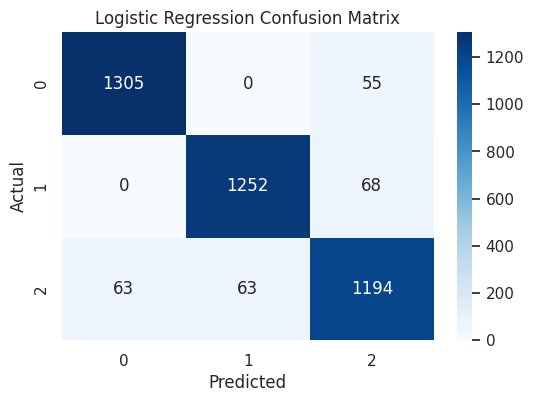



Decision Tree
Accuracy  : 0.8397
Precision : 0.8390
Recall    : 0.8397
F1 Score  : 0.8393

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1360
           1       0.88      0.89      0.88      1320
           2       0.76      0.75      0.76      1320

    accuracy                           0.84      4000
   macro avg       0.84      0.84      0.84      4000
weighted avg       0.84      0.84      0.84      4000



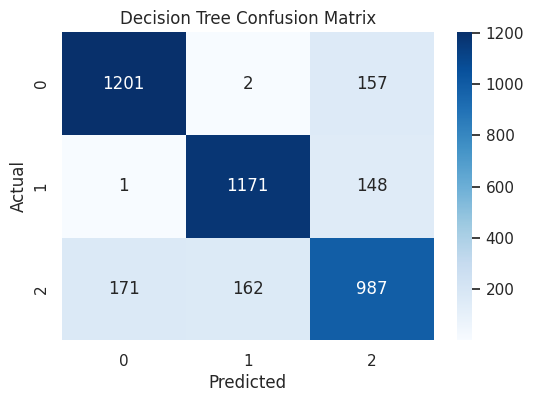



Random Forest
Accuracy  : 0.9065
Precision : 0.9068
Recall    : 0.9065
F1 Score  : 0.9066

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1360
           1       0.93      0.92      0.93      1320
           2       0.85      0.86      0.86      1320

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000



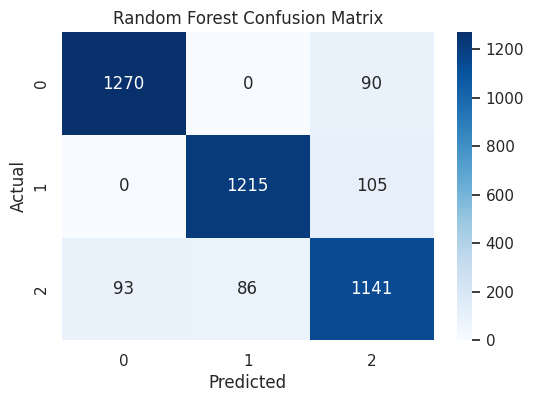



Extra Trees
Accuracy  : 0.8952
Precision : 0.8953
Recall    : 0.8952
F1 Score  : 0.8953

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1360
           1       0.92      0.92      0.92      1320
           2       0.84      0.84      0.84      1320

    accuracy                           0.90      4000
   macro avg       0.90      0.89      0.89      4000
weighted avg       0.90      0.90      0.90      4000



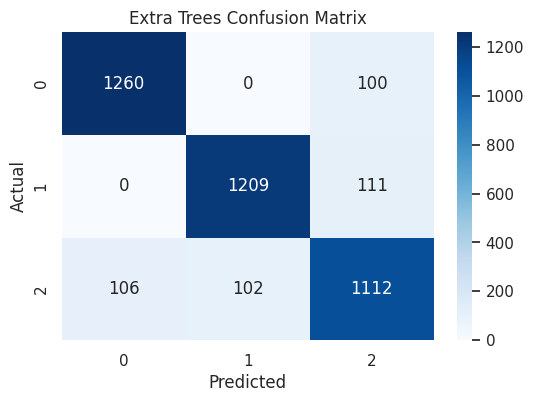



Gradient Boosting
Accuracy  : 0.9133
Precision : 0.9136
Recall    : 0.9133
F1 Score  : 0.9134

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1360
           1       0.94      0.93      0.94      1320
           2       0.86      0.88      0.87      1320

    accuracy                           0.91      4000
   macro avg       0.91      0.91      0.91      4000
weighted avg       0.91      0.91      0.91      4000



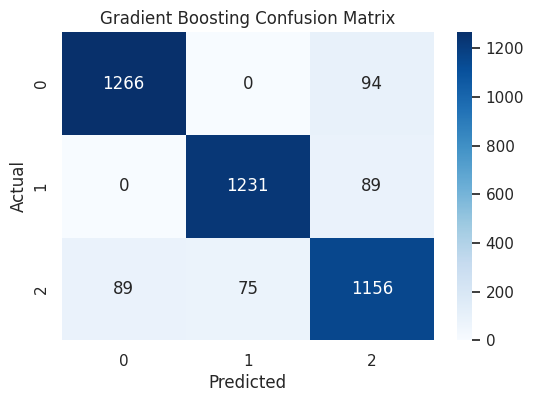



KNN
Accuracy  : 0.8120
Precision : 0.8107
Recall    : 0.8120
F1 Score  : 0.8113

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1360
           1       0.85      0.86      0.85      1320
           2       0.72      0.70      0.71      1320

    accuracy                           0.81      4000
   macro avg       0.81      0.81      0.81      4000
weighted avg       0.81      0.81      0.81      4000



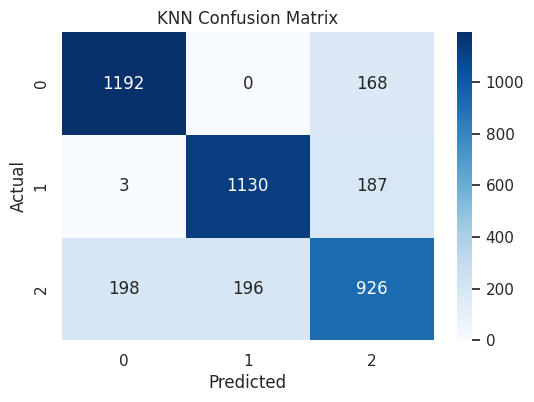



SVM
Accuracy  : 0.9457
Precision : 0.9459
Recall    : 0.9457
F1 Score  : 0.9458

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1360
           1       0.96      0.95      0.96      1320
           2       0.91      0.92      0.92      1320

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



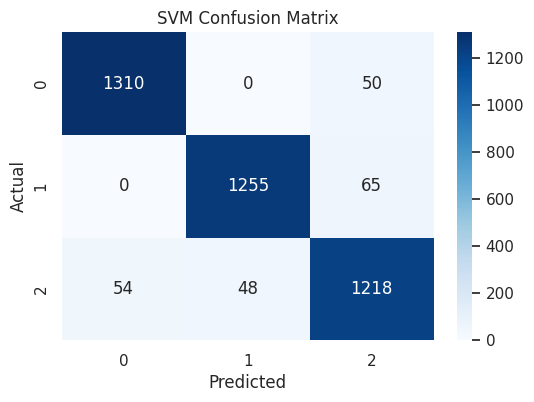



MODEL COMPARISON
                 Model  Accuracy  Precision   Recall        F1
6                  SVM   0.94575   0.945913  0.94575  0.945810
0  Logistic Regression   0.93775   0.937712  0.93775  0.937727
4    Gradient Boosting   0.91325   0.913616  0.91325  0.913409
2        Random Forest   0.90650   0.906821  0.90650  0.906634
3          Extra Trees   0.89525   0.895311  0.89525  0.895275
1        Decision Tree   0.83975   0.838965  0.83975  0.839313
5                  KNN   0.81200   0.810710  0.81200  0.811258


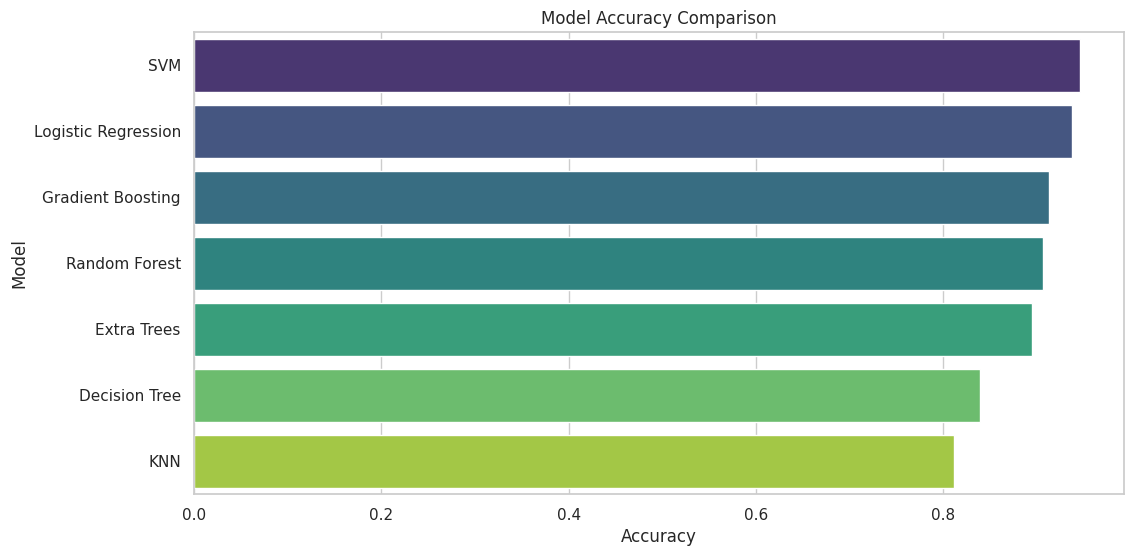


Multiclass Target Detected.
Use One-vs-Rest ROC.

Training Complete.


In [15]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    LabelEncoder
)

from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ==========================================================
# LOAD DATA
# ==========================================================

# df = pd.read_csv("your_file.csv")

print(df.head())

# ==========================================================
# TARGET
# ==========================================================

target = "Layoff_Risk"

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop(columns=[target])

y = df[target]

# ==========================================================
# ENCODE TARGET ONLY
# ==========================================================

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("\nTarget Classes")
print(target_encoder.classes_)

# ==========================================================
# DETECT COLUMN TYPES
# ==========================================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCategorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# ==========================================================
# PREPROCESSING
# ==========================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=500
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(),

    "SVM":
        SVC(
            probability=True
        )
}

# ==========================================================
# RESULTS STORAGE
# ==========================================================

results = []

# ==========================================================
# TRAIN MODELS
# ==========================================================

for name, model in models.items():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # TRAIN
    pipe.fit(X_train, y_train)

    # PREDICTION
    y_pred = pipe.predict(X_test)

    # METRICS
    acc = accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    rec = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append([
        name,
        acc,
        prec,
        rec,
        f1
    ])

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    print("\nClassification Report")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # CONFUSION MATRIX
    plt.figure(figsize=(6,4))

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"{name} Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

print(results_df)

# ==========================================================
# BARPLOT COMPARISON
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title(
    "Model Accuracy Comparison"
)

plt.show()

# ==========================================================
# ROC CURVE
# ==========================================================

# Works best for binary classification
# If multiclass, use OvR ROC below

if len(np.unique(y)) == 2:

    best_model_name = results_df.iloc[0]["Model"]

    best_model = models[best_model_name]

    best_pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", best_model)
        ]
    )

    best_pipe.fit(
        X_train,
        y_train
    )

    y_prob = best_pipe.predict_proba(
        X_test
    )[:,1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.4f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

else:

    print(
        "\nMulticlass Target Detected."
    )

    print(
        "Use One-vs-Rest ROC."
    )

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

rf_pipe.fit(
    X_train,
    y_train
)

print("\nTraining Complete.")